In [2]:
import sys
print(sys.executable)

c:\Users\iamga\Live_Stock_Analysis_Prediction\venv\Scripts\python.exe


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import datetime

print("Environment is ready!")

Environment is ready!


In [4]:
ticker = "HDFCBANK.NS"

In [5]:
df = yf.download(
    ticker,
    start="2020-01-01",
    end=datetime.today().strftime("%Y-%m-%d"),
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [6]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
Date,,,,,
2020-01-01,595.677124,596.329371,591.950065,594.512418,3673698
2020-01-02,599.474182,600.056535,595.863594,595.863594,6137166
2020-01-03,590.925232,598.658868,588.688974,597.354375,10855550
2020-01-06,578.136780,587.850474,575.830685,587.011863,10890186
2020-01-07,587.291321,592.346133,583.401214,586.499343,14724494


In [7]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
Date,,,,,
2026-06-25,796.299988,804.450012,794.750000,798.500000,46707966
2026-06-26,796.299988,796.299988,796.299988,796.299988,0
2026-06-29,798.900024,805.900024,793.299988,800.000000,46695977
2026-06-30,797.950012,806.099976,792.750000,806.099976,45778356
2026-07-01,796.150024,802.250000,793.500000,793.500000,26094378


In [8]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1611 entries, 2020-01-01 to 2026-07-01
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, HDFCBANK.NS)   1611 non-null   float64
 1   (High, HDFCBANK.NS)    1611 non-null   float64
 2   (Low, HDFCBANK.NS)     1611 non-null   float64
 3   (Open, HDFCBANK.NS)    1611 non-null   float64
 4   (Volume, HDFCBANK.NS)  1611 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 75.5 KB


In [9]:
print(df.shape)

(1611, 5)


In [10]:
df.isnull().sum()

Price   Ticker     
Close   HDFCBANK.NS    0
High    HDFCBANK.NS    0
Low     HDFCBANK.NS    0
Open    HDFCBANK.NS    0
Volume  HDFCBANK.NS    0
dtype: int64

In [11]:
df.to_csv("../data/raw/HDFC_stock.csv")

In [12]:
stock = pd.read_csv("../data/raw/HDFC_stock.csv")

stock.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,595.6771240234375,596.3293706466624,591.9500654568958,594.5124182213932,3673698
3,2020-01-02,599.4741821289062,600.056535132723,595.8635935052428,595.8635935052428,6137166
4,2020-01-03,590.9252319335938,598.658868195343,588.6889737244671,597.3543747616177,10855550


In [13]:
stock.describe()

,Price,Close,High,Low,Open,Volume
count,1613,1612,1612,1612,1612,1612
unique,1613,1573,1612,1611,1612,1608
top,Ticker,973.6956176757812,HDFCBANK.NS,976.8435431850351,HDFCBANK.NS,0
freq,1,3,1,2,1,5


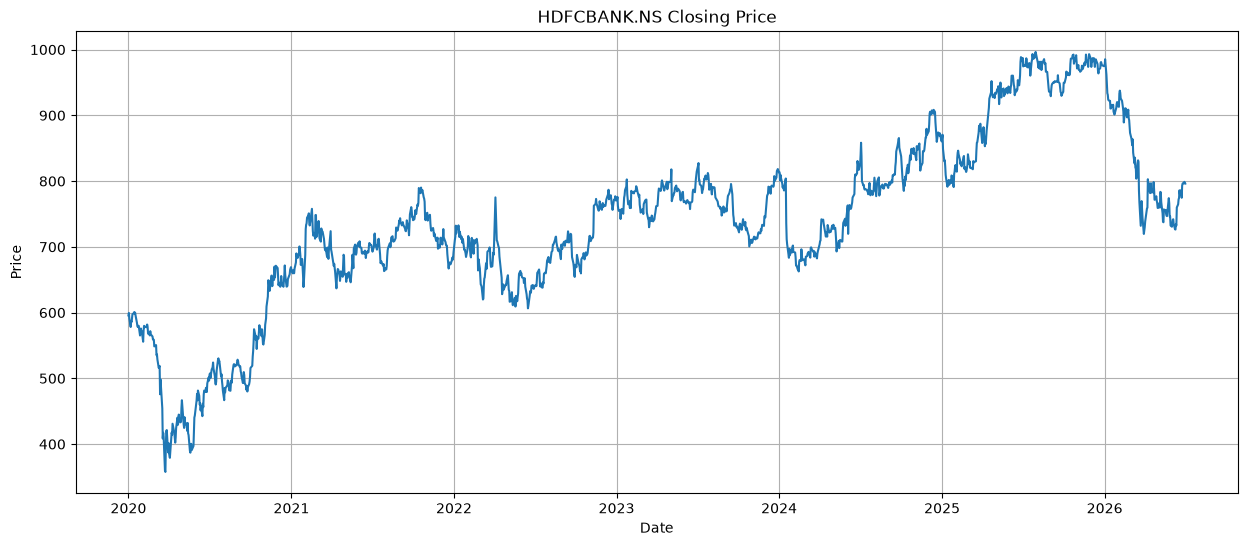

In [14]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Close"])

plt.title(f"{ticker} Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

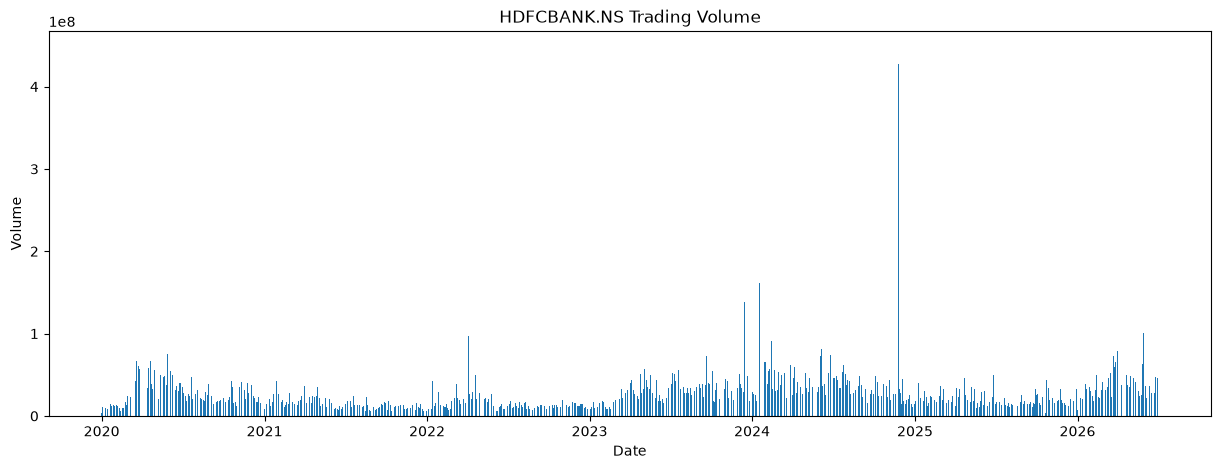

In [15]:
volume = df[("Volume", ticker)]

plt.figure(figsize=(15,5))
plt.bar(df.index, volume)

plt.title(f"{ticker} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [16]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close Price"
    )
)

fig.update_layout(
    title=f"{ticker} Stock Price",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig.show()

In [17]:
print(df.columns)

MultiIndex([( 'Close', 'HDFCBANK.NS'),
            (  'High', 'HDFCBANK.NS'),
            (   'Low', 'HDFCBANK.NS'),
            (  'Open', 'HDFCBANK.NS'),
            ('Volume', 'HDFCBANK.NS')],
           names=['Price', 'Ticker'])


In [18]:
df["Close"]

Ticker,HDFCBANK.NS
Date,
2020-01-01,595.677124
2020-01-02,599.474182
2020-01-03,590.925232
2020-01-06,578.136780
2020-01-07,587.291321
...,...
2026-06-25,796.299988
2026-06-26,796.299988
2026-06-29,798.900024
